In [1]:
import pickle
import os
import numpy as np
import pandas as pd
from skimage.io import imread, imsave, imshow
from skimage.morphology import opening, disk, binary_dilation, convex_hull_image
from skimage.measure import label, regionprops
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt

In [2]:
def get_cell_body(mask, radius_fraction=0.1, min_fraction=0.02, visualize=False):

    mask = mask.astype(bool)

    if mask.sum() == 0:
        if visualize:
            plt.imshow(mask, cmap="gray")
            plt.title("Empty Mask")
            plt.axis("off")
            plt.show()
        return np.zeros_like(mask, dtype=bool)

    region = regionprops(label(mask))[0]
    area = region.area

    r_eq = np.sqrt(area / np.pi)

    frac = radius_fraction
    body = None

    while frac >= min_fraction:

        radius = max(2, int(frac * r_eq))

        opened = opening(mask, disk(radius))

        # if opening removed everything → reduce radius
        if opened.sum() == 0:
            frac *= 0.7
            continue

        body_candidate = convex_hull_image(opened)
        body_candidate &= mask

        if body_candidate.sum() > 0:
            body = body_candidate
            break

        frac *= 0.7   # reduce by 30%

    if body is None:
        body = mask.copy()

    if visualize:

        fig, ax = plt.subplots(1,3, figsize=(12,4))

        ax[0].imshow(mask, cmap="gray")
        ax[0].set_title("Original")

        ax[1].imshow(opened, cmap="gray")
        ax[1].set_title(f"Opening (radius={radius})")

        ax[2].imshow(body, cmap="gray")
        ax[2].set_title("Cell Body")

        for a in ax:
            a.axis("off")

        plt.show()

    return body

In [3]:
main_dir = '/proj/telston_lab/projects/data/DataForTFM/TFM_Data_02242025'

In [4]:
all_names_wt = []
all_names_arpc2ko = []

tracknames_wt = []
tracknames_arpc2ko = []

exp_list = os.listdir(main_dir)
for exp in exp_list:
    if not exp.startswith(".") and '2025_01_30_Jr20Overnight' not in exp and 'Duo_Seg' not in exp and 'skeleton_figs' not in exp:
        treatment_list = os.listdir(main_dir+'/'+exp)
        for treatment in treatment_list:
            if not treatment.startswith("."):
                track_list = os.listdir(main_dir+'/'+exp+'/'+treatment)
                for track in track_list:
                    if not track.startswith("."):
                        basepath = main_dir+'/'+exp+'/'+treatment+'/'+track
                        mask_dir = basepath + '/masks'

                        
                        date = exp.split('_')
                        date = date[0]+date[1]+date[2]
                        
                        track_name = date + "_" + treatment + "_" + track

                        t_list = os.listdir(mask_dir)
                        for t_file in t_list:
                            if not t_file.startswith(".") and t_file.endswith('.tif'):
                                if 'WT' in mask_dir:
                                    all_names_wt.append(mask_dir+'/'+t_file)
                                    tracknames_wt.append(track_name+'_t'+t_file.strip('.tif'))
                                else:
                                    all_names_arpc2ko.append(mask_dir+'/'+t_file)
                                    tracknames_arpc2ko.append(track_name+'_t'+t_file.strip('.tif'))

In [5]:
len(all_names_wt)

13377

In [6]:
tracknames_wt[0]

'20240906_WT_movie16_track6_t47'

In [7]:
len(all_names_arpc2ko)

15720

In [8]:
np.random.seed(550)
rand_wt = np.random.randint(low=0,high=len(all_names_wt),size=5)
rand_arpc2ko = np.random.randint(low=0,high=len(all_names_arpc2ko),size=5)

mask_names_wt = np.array(all_names_wt)[rand_wt]
mask_names_arpc2ko = np.array(all_names_arpc2ko)[rand_arpc2ko]

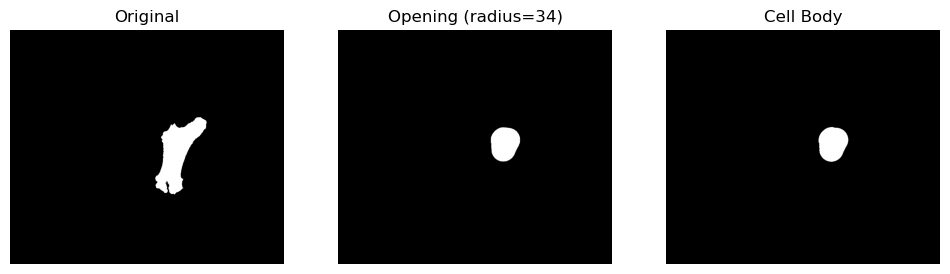

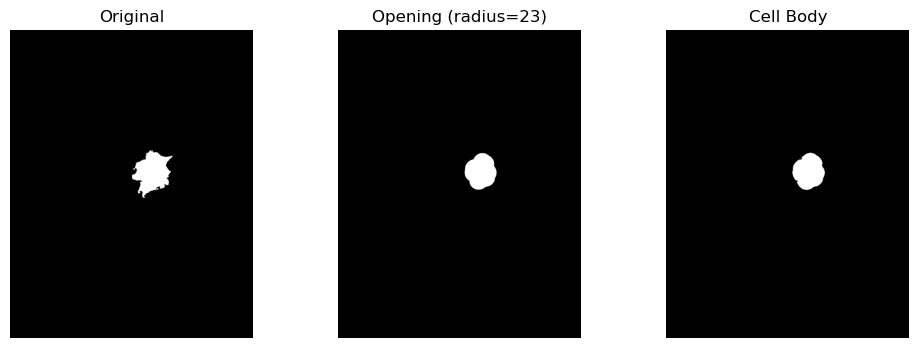

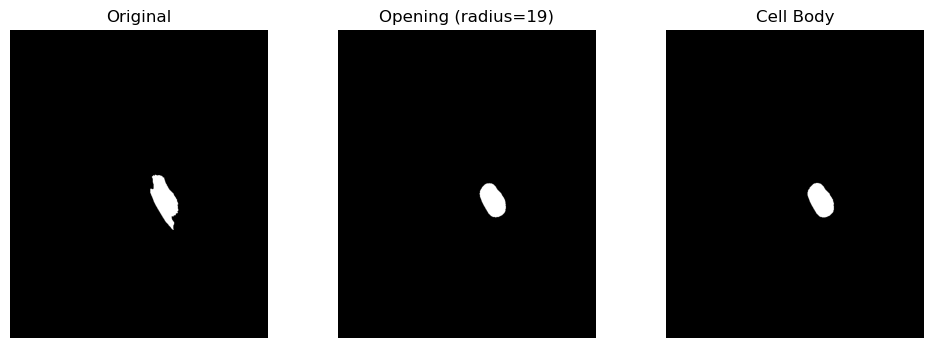

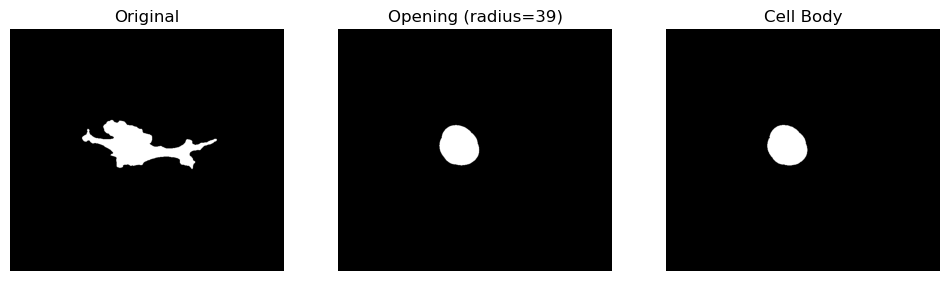

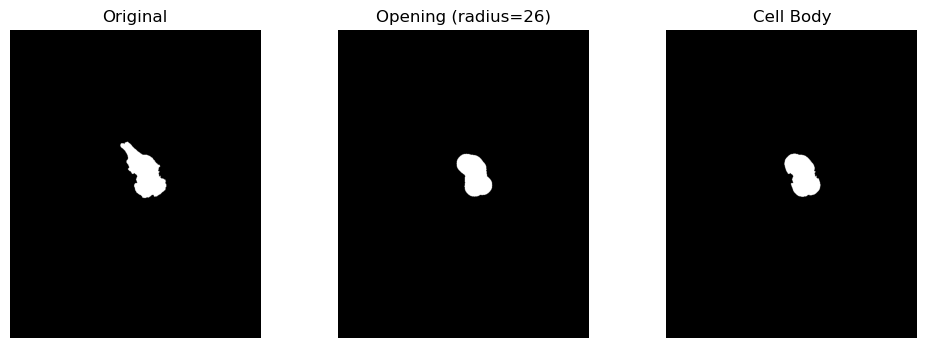

In [9]:
for name in mask_names_wt:
    rad_frac = 0.5
    mask = imread(name)
    body = get_cell_body(mask,radius_fraction=rad_frac,visualize=True)

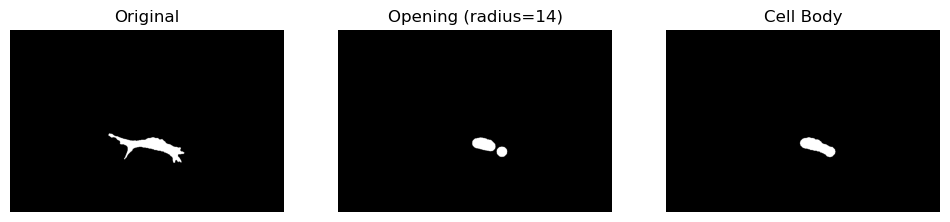

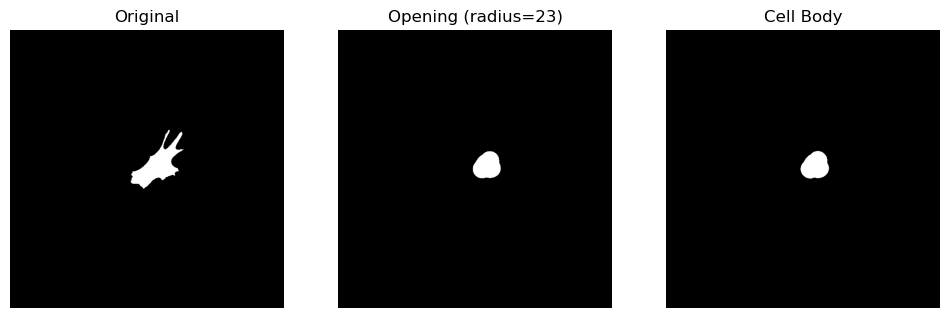

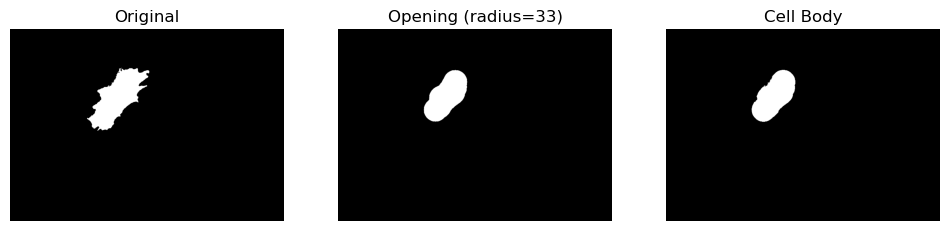

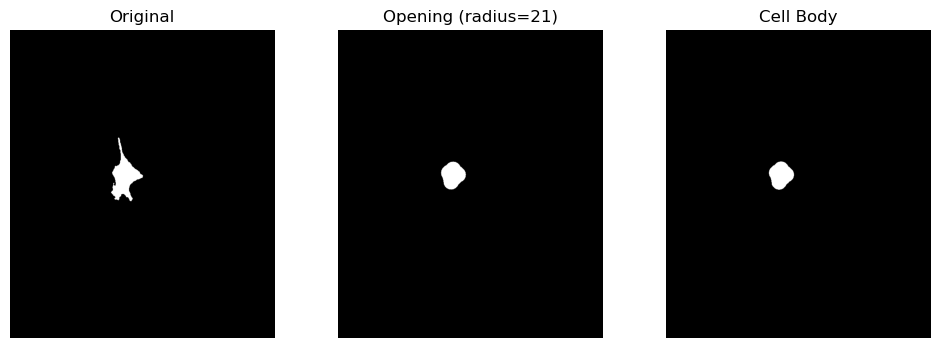

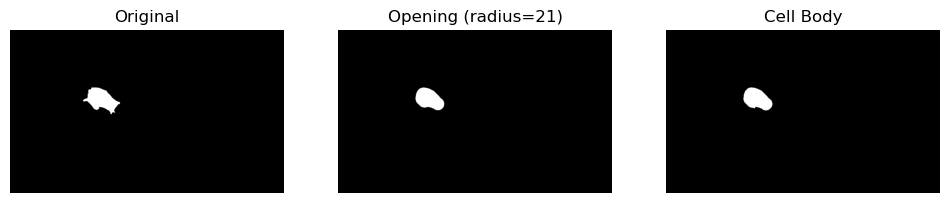

In [10]:
for name in mask_names_arpc2ko:
    rad_frac = 0.5
    mask = imread(name)
    body = get_cell_body(mask,radius_fraction=rad_frac,visualize=True)

In [11]:
gfp_names_wt = []
gfp_names_arpc2ko = []

for name in mask_names_wt:
    gfp_names_wt.append(name.replace('masks','gfp'))

for name in mask_names_arpc2ko:
    gfp_names_arpc2ko.append(name.replace('masks','gfp'))

ref_tracknames_wt = np.array(tracknames_wt)[rand_wt]
ref_tracknames_arpc2ko = np.array(tracknames_arpc2ko)[rand_arpc2ko]

In [92]:
for i in range(5):
    plt.figure(dpi=300)
    plt.axis('off')
    plt.imshow(imread(gfp_names_wt[i]))
    rad_frac = 0.5
    mask = imread(mask_names_wt[i])
    body = get_cell_body(mask,radius_fraction=rad_frac,visualize=False)
    plt.contour(mask, colors="yellow", linewidths=1)
    plt.contour(body, colors="red", linewidths=1)
    plt.savefig('CellBody_Examp/{}_cellbody.pdf'.format(ref_tracknames_wt[i]),format='pdf',bbox_inches='tight')
    plt.clf()

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

In [12]:
for i in range(5):
    plt.figure(dpi=300)
    plt.axis('off')
    plt.imshow(imread(gfp_names_arpc2ko[i]))
    rad_frac = 0.5
    mask = imread(mask_names_arpc2ko[i])
    body = get_cell_body(mask,radius_fraction=rad_frac,visualize=False)
    plt.contour(mask, colors="yellow", linewidths=1)
    plt.contour(body, colors="red", linewidths=1)
    plt.savefig('CellBody_Examp/{}_cellbody.pdf'.format(ref_tracknames_arpc2ko[i]),format='pdf',bbox_inches='tight')
    plt.clf()

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>

<Figure size 1920x1440 with 0 Axes>